In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
!pip install ultralytics
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


1. CẤU HÌNH HỆ THỐNG

In [4]:
BASE_DIR = "/content/drive/MyDrive/CS231 - Nhập Môn Thị Giác Máy Tính/Source/Dataset"
MODEL_YOLO_PATH = "yolo26s-pose.pt"
SAVE_MODEL_PATH = "models/lstm_model_4class.pth"

# Tạo thư mục lưu model
os.makedirs("models", exist_ok=True)
os.makedirs("Dataset", exist_ok=True)

LABELS_MAP = {"Len_Dung": 0, "Xuong_Dung": 1, "Len_Sai": 2, "Xuong_Sai": 3}
TARGET_NAMES = list(LABELS_MAP.keys())
SEQUENCE_LENGTH = 30
BATCH_SIZE_YOLO = 32

2. HÀM TRÍCH XUẤT ĐẶC TRƯNG TỪ VIDEO (YOLO)

In [ ]:
device = '0' if torch.cuda.is_available() else 'cpu'
print(f"[*] Đang chạy trích xuất trên thiết bị: {device}")

def calculate_angle(a, b, c):
    ba, bc = np.array(a) - np.array(b), np.array(c) - np.array(b)
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return round(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))), 2)

def extract_features(kps, prev_angles):
    l_shoulder = calculate_angle(kps[7][:2], kps[5][:2], kps[11][:2])
    r_shoulder = calculate_angle(kps[8][:2], kps[6][:2], kps[12][:2])
    current_angles = [l_shoulder, r_shoulder]
    velocities = [0.0, 0.0] if prev_angles is None else [cur - prev for cur, prev in zip(current_angles, prev_angles)]
    return current_angles + velocities, current_angles

def extract_dataset(split="train"):
    yolo_model = YOLO(MODEL_YOLO_PATH)
    all_rows = []
    print(f"\n--- BẮT ĐẦU TRÍCH XUẤT: TẬP {split.upper()} ---")

    for label_name, label_id in LABELS_MAP.items():
        folder_path = os.path.join(BASE_DIR, split, label_name)
        if not os.path.exists(folder_path): continue

        # In ra tên Nhãn đang xử lý
        print(f"\nNHÃN: {label_name} (ID: {label_id})")

        video_files = [f for f in os.listdir(folder_path) if f.endswith(('.mp4', '.avi'))]
        for v_file in video_files:
            video_path = os.path.join(folder_path, v_file)
            cap = cv2.VideoCapture(video_path)

            # Tính tổng số frame và in ra tên video đang xử lý
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            print(f"    > Đang xử lý: {v_file} ({total_frames} frames gốc)")

            frames_buffer, prev_angles = [], None
            frame_idx = 0

            while cap.isOpened():
                ret, frame = cap.read()

                if ret:
                    frame = cv2.rotate(frame, cv2.ROTATE_180)
                    frames_buffer.append(frame)
                    frame_idx += 1

                # Khi buffer đầy HOẶC video kết thúc mà buffer vẫn còn ảnh
                if len(frames_buffer) == BATCH_SIZE_YOLO or (not ret and len(frames_buffer) > 0):
                    results = yolo_model(frames_buffer, conf=0.6, verbose=False, device=device)
                    for i, res in enumerate(results):
                        if res.keypoints is not None and len(res.keypoints.data) > 0:
                            boxes = res.boxes.xyxy.cpu().numpy()
                            main_idx = np.argmax((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]))
                            kps = res.keypoints.data[main_idx].cpu().numpy()

                            if kps[5:13, 2].mean() > 0.5:
                                features, prev_angles = extract_features(kps, prev_angles)

                                safe_video_name = f"{label_name}_{v_file}"

                                all_rows.append({
                                    "frame": frame_idx - len(frames_buffer) + i,
                                    "video": safe_video_name, "label": label_id,
                                    "l_sh": features[0], "r_sh": features[1],
                                    "v_l": features[2], "v_r": features[3]
                                })
                    frames_buffer = []
                if not ret: break
            cap.release()

    df = pd.DataFrame(all_rows)
    out_csv = os.path.join(BASE_DIR, f"keypoints_{split}.csv")
    df.to_csv(out_csv, index=False)
    print(f"\n[OK] Đã lưu {len(df)} dòng vào: {out_csv}")

# Chạy trích xuất cho cả Train và Test
extract_dataset("train")
extract_dataset("test")

[*] Đang chạy trích xuất trên thiết bị: 0

--- BẮT ĐẦU TRÍCH XUẤT: TẬP TRAIN ---

NHÃN: Len_Dung (ID: 0)
    > Đang xử lý: 010_00006670.mp4 (81 frames gốc)
    > Đang xử lý: 010_00005033.mp4 (80 frames gốc)
    > Đang xử lý: 010_00009324.mp4 (80 frames gốc)
    > Đang xử lý: 010_00009837.mp4 (89 frames gốc)
    > Đang xử lý: 010_00005665.mp4 (80 frames gốc)
    > Đang xử lý: 010_00004548.mp4 (81 frames gốc)
    > Đang xử lý: 010_00008177.mp4 (85 frames gốc)
    > Đang xử lý: 010_00005822.mp4 (81 frames gốc)
    > Đang xử lý: 010_00006835.mp4 (82 frames gốc)
    > Đang xử lý: 010_00005986.mp4 (90 frames gốc)
    > Đang xử lý: 010_00007013.mp4 (82 frames gốc)
    > Đang xử lý: 010_00004385.mp4 (81 frames gốc)
    > Đang xử lý: 010_00006159.mp4 (84 frames gốc)
    > Đang xử lý: 010_00009157.mp4 (80 frames gốc)
    > Đang xử lý: 010_00004075.mp4 (73 frames gốc)
    > Đang xử lý: 010_00005352.mp4 (75 frames gốc)
    > Đang xử lý: 010_00008832.mp4 (76 frames gốc)
    > Đang xử lý: 010_000100

3. CHUẨN BỊ DỮ LIỆU


In [69]:
def create_sequences(csv_path, step_size):
    df = pd.read_csv(csv_path)
    X, y = [], []
    for video_name, group in df.groupby("video"):
        if len(group) < SEQUENCE_LENGTH: continue
        label = group["label"].iloc[0]
        # Chuẩn hóa
        features = np.hstack([group[["l_sh", "r_sh"]].values / 180.0, group[["v_l", "v_r"]].values / 10.0])
        for start in range(0, len(features) - SEQUENCE_LENGTH + 1, step_size):
            X.append(features[start : start + SEQUENCE_LENGTH])
            y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(os.path.join(BASE_DIR, "keypoints_train.csv"), step_size=10)
X_test, y_test   = create_sequences(os.path.join(BASE_DIR, "keypoints_test.csv"), step_size=30)

np.save("Dataset/X_train.npy", X_train)
np.save("Dataset/y_train.npy", y_train)
np.save("Dataset/X_test.npy", X_test)
np.save("Dataset/y_test.npy", y_test)
print(f"Lưu xong! X_train: {X_train.shape}, X_test: {X_test.shape}")

Lưu xong! X_train: (6411, 30, 4), X_test: (456, 30, 4)


4. Khởi tạo Model & DataLoader

In [123]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' # Correctly define device
X_train = np.load("Dataset/X_train.npy")
y_train = np.load("Dataset/y_train.npy")
X_test  = np.load("Dataset/X_test.npy")
y_test  = np.load("Dataset/y_test.npy")

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=32, shuffle=True)
X_test_t, y_test_t = torch.FloatTensor(X_test).to(device), torch.LongTensor(y_test).to(device)

class BenchPressLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=16, num_layers=2, num_classes=4, dropout=0.55):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

model = BenchPressLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

5. Huấn luyện

Epoch 001/100 | Train Loss: 1.3965 | Val Loss: 1.3811 | Val Acc: 0.3070 (Best)
Epoch 002/100 | Train Loss: 1.2359 | Val Loss: 1.0176 | Val Acc: 0.4803 (Best)
Epoch 003/100 | Train Loss: 0.9235 | Val Loss: 0.8202 | Val Acc: 0.6360 (Best)
Epoch 004/100 | Train Loss: 0.7347 | Val Loss: 0.5823 | Val Acc: 0.7237 (Best)
Epoch 005/100 | Train Loss: 0.5701 | Val Loss: 0.4765 | Val Acc: 0.7412 (Best)
Epoch 006/100 | Train Loss: 0.5170 | Val Loss: 0.5536 | Val Acc: 0.7193 
Epoch 007/100 | Train Loss: 0.4696 | Val Loss: 0.4474 | Val Acc: 0.7390 (Best)
Epoch 008/100 | Train Loss: 0.4553 | Val Loss: 0.4616 | Val Acc: 0.7346 
Epoch 009/100 | Train Loss: 0.4376 | Val Loss: 0.4173 | Val Acc: 0.7434 (Best)
Epoch 010/100 | Train Loss: 0.4351 | Val Loss: 0.4059 | Val Acc: 0.7434 (Best)
Epoch 011/100 | Train Loss: 0.4204 | Val Loss: 0.4399 | Val Acc: 0.7434 
Epoch 012/100 | Train Loss: 0.4125 | Val Loss: 0.4147 | Val Acc: 0.7434 
Epoch 013/100 | Train Loss: 0.4039 | Val Loss: 0.4243 | Val Acc: 0.7434 
Epo

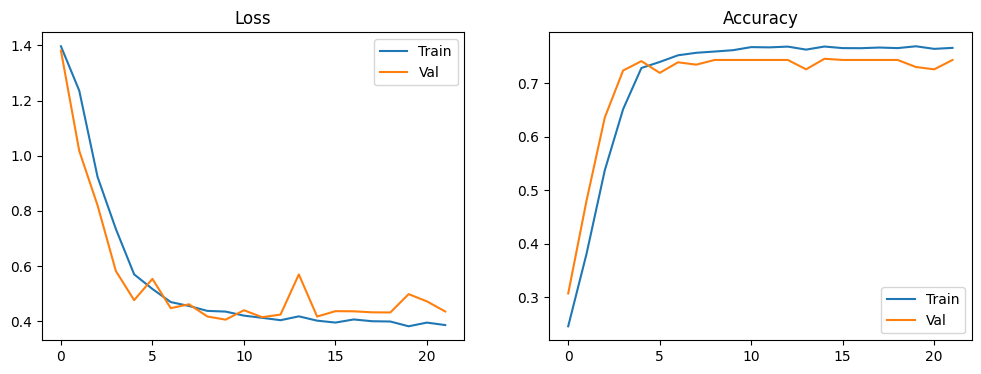

<All keys matched successfully>

In [124]:
EPOCHS = 100
patience = 12
patience_counter = 0
best_val_loss = float('inf')
min_delta = 0.005

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (torch.max(out.data, 1)[1] == yb).sum().item()
        total += yb.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accs.append(correct / total)

    # Validation
    model.eval()
    with torch.no_grad():
        v_out = model(X_test_t)
        val_loss = criterion(v_out, y_test_t).item()
        val_acc = (torch.max(v_out.data, 1)[1] == y_test_t).sum().item() / y_test_t.size(0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    is_best = ""

    if val_loss < (best_val_loss - min_delta):
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_MODEL_PATH)
        is_best = "(Best)"
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {is_best}")

    if patience_counter >= patience:
        print(f"\n[!] EARLY STOPPING kích hoạt ở Epoch {epoch+1}.")
        print(f"[*] Mô hình tốt nhất đã được lưu ở Epoch {epoch+1 - patience}.")
        break

# Vẽ đồ thị
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val'); ax1.set_title("Loss"); ax1.legend()
ax2.plot(train_accs, label='Train'); ax2.plot(val_accs, label='Val'); ax2.set_title("Accuracy"); ax2.legend()
plt.show()

model.load_state_dict(torch.load(SAVE_MODEL_PATH))

6. Đánh giá

In [125]:
print("\nĐang đánh giá mức độ Video (Video-Level Evaluation)...")
model.load_state_dict(torch.load(SAVE_MODEL_PATH))
model.eval()

df_test = pd.read_csv(os.path.join(BASE_DIR, "keypoints_test.csv"))
video_trues, video_preds = [], []


for video_name, group in df_test.groupby("video"):
    if len(group) < SEQUENCE_LENGTH: continue
    true_label = group["label"].iloc[0]

    features = np.hstack([group[["l_sh", "r_sh"]].values / 180.0, group[["v_l", "v_r"]].values / 10.0])

    X_video = [features[i : i + SEQUENCE_LENGTH] for i in range(0, len(features) - SEQUENCE_LENGTH + 1, 5)]
    if not X_video: continue

    with torch.no_grad():
        outputs = model(torch.FloatTensor(np.array(X_video)).to(device))

        middle_idx = len(outputs) // 2
        pred_label = torch.argmax(torch.softmax(outputs[middle_idx:middle_idx+1], dim=1)).item()

    video_trues.append(true_label)
    video_preds.append(pred_label)

print("\n" + "="*50)
print("BÁO CÁO PHÂN LOẠI TRÊN TOÀN BỘ VIDEO")
print("="*50)
print(classification_report(video_trues, video_preds, target_names=TARGET_NAMES, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(video_trues, video_preds))


Đang đánh giá mức độ Video (Video-Level Evaluation)...

BÁO CÁO PHÂN LOẠI TRÊN TOÀN BỘ VIDEO
              precision    recall  f1-score   support

    Len_Dung       0.99      1.00      0.99        96
  Xuong_Dung       1.00      0.99      0.99        96
     Len_Sai       0.00      0.00      0.00        76
   Xuong_Sai       0.50      1.00      0.67        76

    accuracy                           0.78       344
   macro avg       0.62      0.75      0.66       344
weighted avg       0.67      0.78      0.70       344

Confusion Matrix:
[[96  0  0  0]
 [ 1 95  0  0]
 [ 0  0  0 76]
 [ 0  0  0 76]]
